# Experiment 2a — Coupling *and* trial-to-trial baseline variation both present

The paper's synthetic study (`STAR Synthetic dataset; Pillow et al.ipynb`) already covers the two
one-at-a-time cases: **Sensitivity** (coupling, no variation → filter nonzero) and **Time warping**
(no coupling, variation → filter zero). Reviewer 2a asks for the combined case: **both at once**.

On a representative simulation, using confidence intervals as in the main figures, we show:
(1) pop-GLM **with** time warping recovers the coupling filter; (2) **without** time warping the
filter is **inflated** (its CI lies higher), because the unmodelled trial-to-trial variation is
misattributed to coupling; (3) single-neuron GLMs are **noisy and inflated**, since a single neuron
cannot support per-trial time-warping.

Hyperparameters follow the paper's Sensitivity section (EIF, `conn=0.0075`, `ntrial=100`, baseline
`num=20`, coupling `num=3,peaks_max=15,nonlinear=1`, `refractory_additive(tau=10,num=4)`,
`penalty=1e0`, warp `max_iter=5`); variation uses `std1=10,corr1=0.5,std2=25,corr2=0.9`.

In [1]:
import os, sys, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../.."))     # repo root (GLM.py, utility_functions.py)
sys.path.insert(0, os.path.abspath("."))         # this folder (exp2a_ci_fig.py, exp2a_s3.py)
HERE = os.path.abspath(".")
%matplotlib inline
import numpy as np, pickle, matplotlib.pyplot as plt
import utility_functions as utils
import exp2a_ci_fig as F        # provides compute(), panel_pop(ax,D), panel_single(ax,D)

## Fit one representative simulation, with 95% confidence intervals

`compute()` fits pop-GLM with and without time warping (via `get_filter(ci=True)`, the same CI used
for the main figures) and the single-neuron GLMs. The two panels are drawn by `panel_pop` and
`panel_single`, which take a matplotlib axis — so the same code can be dropped into a subplot of the
main synthetic figure (Figure 3) in the future.

coupling-filter integral:  warp = 0.729   no-warp = 1.485   single-neuron mean = 1.469


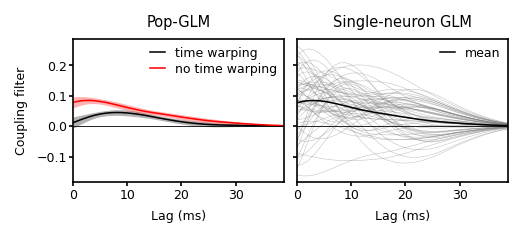

In [2]:
D = F.compute(seed=100)
print("coupling-filter integral:  warp = %.3f   no-warp = %.3f   single-neuron mean = %.3f"
      % (D["fw"].sum(), D["fn"].sum(), D["single"].sum(1).mean()))

utils.use_pdf_plot()                                  # the paper's figure style
fig, (a1, a2) = plt.subplots(1, 2, figsize=(3.4, 1.5), dpi=150, sharey=True)
F.panel_pop(a1, D); F.panel_single(a2, D)
fig.tight_layout(pad=0.4)
from IPython.display import display; display(fig); plt.close(fig)

## Summary across simulations (coupling-filter integral, mean ± sd)

The point estimates above are one representative simulation. The table aggregates the 6 combined-case
and 6 no-variation reference simulations in `exp2a_s3.pkl`.

In [3]:
R = pickle.load(open(os.path.join(HERE, "exp2a_s3.pkl"), "rb")); L = 40
W  = np.array([r["pop_warp"]   for r in R["both"]])[:, :L]
N  = np.array([r["pop_nowarp"] for r in R["both"]])[:, :L]
S  = np.array([f for r in R["both"] for f in r["single"]])[:, :L]
RF = np.array([r["pop_warp"]   for r in R["ref"]])[:, :L]
pw = [r["p_warp"] for r in R["both"]]
print("coupling-filter integral (mean +/- sd across simulations):")
print("  reference (coupling, NO variation)  : %.3f +/- %.3f" % (RF.sum(1).mean(), RF.sum(1).std(ddof=1)))
print("  pop-GLM, time warping ON            : %.3f +/- %.3f" % (W.sum(1).mean(),  W.sum(1).std(ddof=1)))
print("  pop-GLM, NO time warping            : %.3f +/- %.3f" % (N.sum(1).mean(),  N.sum(1).std(ddof=1)))
print("  single-neuron GLM (n=%d filters)   : %.3f +/- %.3f" % (len(S), S.sum(1).mean(), S.sum(1).std(ddof=1)))
print("  pop-GLM (warping) detects coupling in %d/%d sims (LRT p<0.05)" % (sum(p<.05 for p in pw), len(pw)))

coupling-filter integral (mean +/- sd across simulations):
  reference (coupling, NO variation)  : 0.750 +/- 0.171
  pop-GLM, time warping ON            : 0.737 +/- 0.115
  pop-GLM, NO time warping            : 1.535 +/- 0.080
  single-neuron GLM (n=600 filters)   : 1.533 +/- 1.386
  pop-GLM (warping) detects coupling in 5/6 sims (LRT p<0.05)


**Conclusion.** With coupling and trial-to-trial baseline variation both present, **pop-GLM with
time warping recovers the true coupling** — across simulations its integral matches the no-variation
reference (0.74 ± 0.12 vs 0.75 ± 0.17). **Removing time warping biases the estimate upward** (its CI
lies above the warped one; integral inflated ~2×, 1.54 ± 0.08), because the unmodelled trial-to-trial
variation is misattributed to coupling. **Single-neuron GLMs are both noisy and inflated** (sd 1.39
vs 0.08): a single neuron cannot support per-trial shift estimation and so cannot implement time
warping. Pooling across neurons is what makes the correction possible — the argument for a
population-level formulation.